In [1]:
import osmnx as ox

import pandas as pd
import numpy as np

from pathlib import Path

import requests
import json

from rapidfuzz import fuzz
from unidecode import unidecode

from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
import seaborn as sns

import yaml

# Load HCM data

In [2]:
RAW_PATH = Path("../data/raw")

In [3]:
nodes_df = pd.read_csv(RAW_PATH/"nodes.csv")
segments_df = pd.read_csv(RAW_PATH/"segments.csv")
status_df = pd.read_csv(RAW_PATH/"segment_status.csv")
streets_df = pd.read_csv(RAW_PATH/"streets.csv")
train_df = pd.read_csv(RAW_PATH/"train.csv")

In [4]:
status_df["updated_at"] = (
    pd.to_datetime(status_df["updated_at"], utc=True)
    .dt.tz_localize(None)
)

In [5]:
train_df

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,NaN,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33436,33436,84529,2021-01-05,1,period_8_00,F,411918572,1226517262,13,654864528,NaN,2,Nguyễn Thị Minh Khai,primary,106.704503,10.789614,106.704584,10.789702
33437,33437,84533,2021-01-09,5,period_13_30,F,4597281310,411918528,126,654864530,NaN,4,Nguyễn Bỉnh Khiêm,tertiary,106.704986,10.787267,106.704149,10.788051
33438,33438,84533,2021-04-22,3,period_5_00,F,4597281310,411918528,126,654864530,NaN,4,Nguyễn Bỉnh Khiêm,tertiary,106.704986,10.787267,106.704149,10.788051
33439,33439,84534,2021-01-09,5,period_13_30,D,411918528,411925985,89,654864530,NaN,4,Nguyễn Bỉnh Khiêm,tertiary,106.704149,10.788051,106.703549,10.788604


In [6]:
# Quy date + period của train về cùng mốc thời gian 30 phút với status.
time_parts = train_df["period"].str.extract(
    r"^period_(\d{1,2})_(\d{2})$",
    expand=True,
).astype(int)

train_df["timestamp"] = (
    pd.to_datetime(train_df["date"])
    + pd.to_timedelta(time_parts[0], unit="h")
    + pd.to_timedelta(time_parts[1], unit="m")
)
status_df["timestamp"] = status_df["updated_at"].dt.floor("30min")

In [7]:
# Một segment có thể có nhiều status trong cùng 30 phút; lấy velocity trung bình
# để mỗi khóa (segment_id, timestamp) chỉ còn một dòng.
status_30m_df = (
    status_df.groupby(["segment_id", "timestamp"], as_index=False)
    .agg(
        velocity=("velocity", "mean"),
        status_count=("velocity", "size"),
    )
)

In [8]:
merged_df = train_df.merge(
    status_30m_df,
    how="left",
    on=["segment_id", "timestamp"],
    validate="one_to_one",
)

print(f"Số dòng sau merge: {len(merged_df):,}")
print(f"Số dòng không khớp status: {merged_df['velocity'].isna().sum():,}")
merged_df.head()

Số dòng sau merge: 33,441
Số dòng không khớp status: 0


,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,...,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp,velocity,status_count
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,...,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422,2021-04-16 00:30:00,117.0,1
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-02 23:30:00,30.0,2
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-03 00:00:00,20.0,8
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-09 09:30:00,33.0,1
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-23 09:30:00,32.0,1


In [9]:
merged_df.head()

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,...,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp,velocity,status_count
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,...,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422,2021-04-16 00:30:00,117.0,1
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-02 23:30:00,30.0,2
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-03 00:00:00,20.0,8
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-09 09:30:00,33.0,1
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-23 09:30:00,32.0,1


In [10]:
merged_df["velocity"] = merged_df["velocity"].fillna(40)

{'whiskers': [<matplotlib.lines.Line2D at 0x19fed351580>,
 'caps': [<matplotlib.lines.Line2D at 0x19fed353f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x19fed3521b0>],
 'medians': [<matplotlib.lines.Line2D at 0x19fed352c30>],
 'fliers': [<matplotlib.lines.Line2D at 0x19fed352330>],
 'means': []}

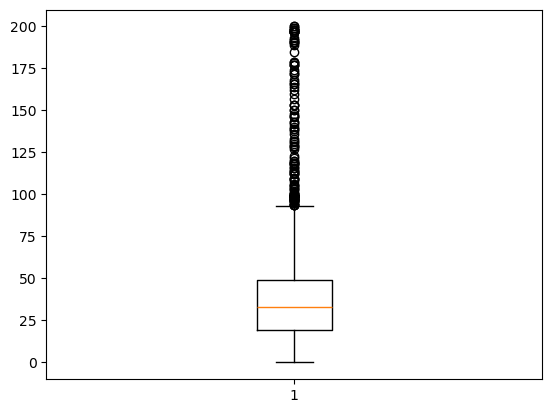

In [11]:
plt.boxplot(merged_df["velocity"])

In [12]:
merged_df["velocity"].max()

np.float64(200.0)

In [13]:
merged_df["velocity"].min()

np.float64(0.0)

In [14]:
merged_df["velocity"].mean()

np.float64(33.48063119268923)

In [18]:
np.quantile(merged_df["velocity"], 0.25)

np.float64(19.375)

In [19]:
np.quantile(merged_df["velocity"], 0.75)

np.float64(49.0)